Predicted Document Type: resume (Confidence: 97.80%)


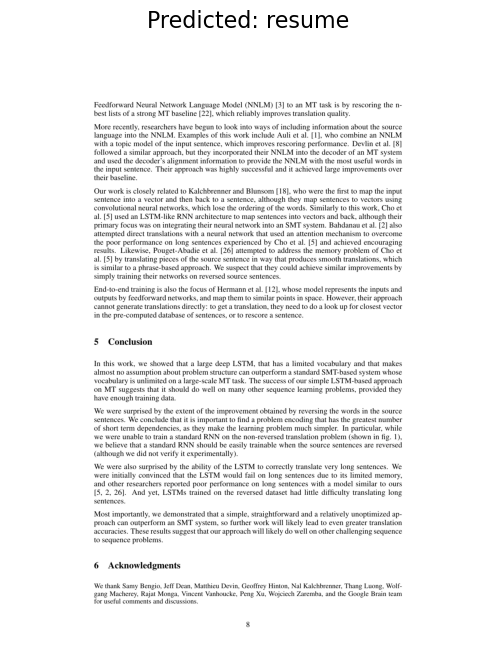

In [11]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load the trained model and class names
model_path = "../models/doc_classifier_resnet18.pth"
checkpoint = torch.load(model_path)
class_names = checkpoint['class_names']

# Initialize ResNet18 architecture and load weights
model = models.resnet18()
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set to evaluation mode

# 2. Define the same transforms used during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Load a new test image (Change this to a image in your data/raw folder)
# Let's test on a PDF page!
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.preprocessing.pipeline import render_pdf_page
test_img = render_pdf_page("../data/raw/seq-2-seq.pdf", page_num=7, dpi=150)

# Convert to PIL Image for transforms
pil_img = Image.fromarray(test_img)
input_tensor = transform(pil_img).unsqueeze(0) # Add batch dimension

# 4. Predict
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted = torch.max(outputs, 1)
    confidence = torch.nn.functional.softmax(outputs, 1)[0] * 100
    predicted_class = class_names[predicted[0]]

print(f"Predicted Document Type: {predicted_class} (Confidence: {confidence[predicted[0]].item():.2f}%)")

# 5. Visualize
plt.figure(figsize=(8, 8))
plt.imshow(test_img)
plt.title(f"Predicted: {predicted_class}", fontsize=16)
plt.axis('off')
plt.show()